[<img src='https://github.com/jeshraghian/snntorch/blob/master/docs/_static/img/snntorch_alpha_w.png?raw=true' width="300">](https://github.com/jeshraghian/snntorch)

# Introduction to delta neurons in spiking neural networks
### Tutorial written by Danny Chia and Jason You

<!-- TO DO: link to repository once code is merged into the stable release -->
<!--
<a href="https://colab.research.google.com/github/jeshraghian/snntorch/blob/master/examples/quickstart.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>
-->

[<img src='https://github.com/jeshraghian/snntorch/blob/master/docs/_static/img/GitHub-Mark-Light-120px-plus.png?raw=true' width="28">](https://github.com/jeshraghian/snntorch/) [<img src='https://github.com/jeshraghian/snntorch/blob/master/docs/_static/img/GitHub_Logo_White.png?raw=true' width="80">](https://github.com/jeshraghian/snntorch)

## Abstract

Spiking neural networks (SNNs) are a type of artificial neural network (ANN) that aims to mimic real biological neurons. Such networks often use the leaky integrate-and-fire (LIF) model in which the potential in the membrane is treated as a leaky capacitor. SNNs consume much less power than traditional neural networks because SNNs encode information in binary spikes and do not rely on costly matrix operations. However, many methods and iterations of SNNs are still under-researched. We introduce a variant of spiking neurons called delta spiking neurons to snnTorch. By altering the LIF model in the neuron, we are able to introduce a delta threshold to store the predefined or learned value that will act as a sensitivity filter. This will allow neurons to only spike when there is a significant change, further reducing power consumption.

## Introduction

Unlike traditional ANNs, SNNs are driven by events and only process data when a spike is detected. Standard SNN frameworks such as snnTorch typically adopt the LIF model at the core: spikes are generated when the membrane potential exceeds a specific threshold. However, many events occurring in nature are more accurately described as changes over time rather than magnitudes.

Examples include power grid fluctuations, network traffic spikes due to cyber attacks, and physiological signals (such as heart rates and brain waves).

# Background

A delta network computes the difference between the current state and the last transmitted state, and updates are sent only if the difference exceeds the predefined threshold. With this approach minor fluctuations are ignored, suppressing noise and redundancy in spiking activity. This allows reduced communication costs while keeping task relevant information, demonstrating both computational and energy efficiency advantages. Delta networks compute state changes using these formulas:

$$ \Delta x_t = x_t - x_{t - 1} $$

$$ \begin{equation}
  E_t = \begin{cases}
    \Delta x_t, & |\Delta x_t| \geq Θ_Δ \\
    0, & \text{otherwise}.
  \end{cases}
\end{equation} $$

$ {x_t} $ represents the current network state, $ {x_{t - 1}} $ is the last transmitted state, and $ Θ_Δ $ is the threshold that controls the sensitivity to state changes. Delta networks also support negative spikes, which can reduce the membrane potential and prevent excessive firing of spikes from previous time steps. This can help reduce latency as well as achieve greater information capacity compared to standard LIF neurons.

## About the `DeltaLeaky` class

We keep the standard equation for updating the membrane potential but introduce a variable $ {U_Δ} $ for storing the change in potential:

$$ U_Δ = U_{t + 1} - U_t $$

In this case, the neuron fires a spike when the change exceeds a predefined threshold:

$$ \begin{equation}
  S_t = \begin{cases}
    1, & U_Δ \geq \Delta_{thr} \\
    0, & \text{otherwise}.
  \end{cases}
\end{equation} $$

The above is to be implemented in the modified `forward()` function in a fork of the `leaky.py` class. This tutorial provides an example that uses this `DeltaLeaky` neuron type.

## 0. Set up environment

Download and install snnTorch package.

In [1]:
!git clone -b feature/delta-SNNs https://github.com/ixfd64/snntorch.git
%cd snntorch
!python setup.py install

# TO DO: use proper installation method once code is merged into the stable branch
# !pip install snntorch --quiet

Cloning into 'snntorch'...
remote: Enumerating objects: 7228, done.
remote: Counting objects: 100% (1892/1892), done.
remote: Compressing objects: 100% (467/467), done.
remote: Total 7228 (delta 1661), reused 1427 (delta 1425), pack-reused 5336 (from 2)
Receiving objects: 100% (7228/7228), 55.25 MiB | 34.43 MiB/s, done.
Resolving deltas: 100% (4937/4937), done.
/content/snntorch
/usr/local/lib/python3.12/dist-packages/setuptools/_distutils/dist.py:261: UserWarning: Unknown distribution option: 'test_suite'
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/setuptools/_distutils/dist.py:261: UserWarning: Unknown distribution option: 'tests_require'
  warnings.warn(msg)
running install
/usr/local/lib/python3.12/dist-packages/setuptools/_distutils/cmd.py:66: SetuptoolsDeprecationWarning: setup.py install is deprecated.
!!

        ********************************************************************************
        Please avoid running ``setup.py`` directly.
        Instead, 

Import required libraries.

In [2]:
import torch, torch.nn as nn
import snntorch as snn
import matplotlib.pyplot as plt

from snntorch import utils

Define parameters and initialize neuron.

In [3]:
num_steps = 100     # time steps
beta = 0.8          # membrane potential decay rate

# initialize neuron
neuron = snn.DeltaLeaky(beta=beta, delta_threshold=0.3, init_hidden=True, output=True)

# simulate input current
cur_in = torch.ones(num_steps) * 0.5
# Ensure the current exceeds the threshold after some integration time
cur_in[num_steps // 2:] = 1.2

mem_rec = []    # store membrane potential
spk_rec = []    # store spikes

# initial reset
utils.reset(neuron)

Process the input and membrane potential.

In [4]:
# simulate input current
cur_in = torch.ones(num_steps) * 0.5
# ensure current exceeds the threshold after some integration time
cur_in[num_steps // 2:] = 1.2

mem_rec = []    # store membrane potential
spk_rec = []    # store spikes

# initial reset
utils.reset(neuron)

# simulate the neuron over time
for step in range(num_steps):
    # process current input and previous membrane potential
    spk_out, mem_out = neuron(cur_in[step])

    # store outputs
    mem_rec.append(mem_out)
    spk_rec.append(spk_out)

# convert output lists to tensors
mem_rec = torch.stack(mem_rec)
spk_rec = torch.stack(spk_rec)

Visualize the results.

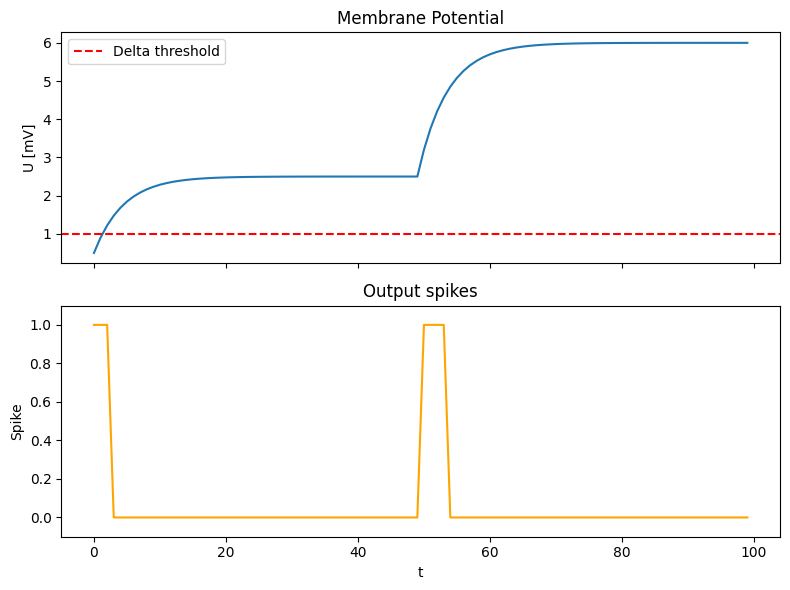

In [5]:
fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# plot membrane potential
ax[0].plot(mem_rec.detach().numpy())
ax[0].set_title('Potential')
ax[0].set_ylabel('U [mV]')
ax[0].axhline(y=neuron.threshold.item(), color='r', linestyle='--', label='Delta threshold')
ax[0].legend()

# plot spikes
ax[1].plot(spk_rec.detach().numpy(), color='orange')
ax[1].set_title('Output spikes')
ax[1].set_xlabel('t')
ax[1].set_ylabel('Spike')
ax[1].set_ylim(-0.1, 1.1)

plt.tight_layout()
plt.show()


# Conclusion
Delta neurons have a lot of potential (no pun intended) and is under active research. It could result in more efficient machine learning and AI models that use far less power. The possible applications of delta neurons and SNNs as a while remain to be seen.